# Abgabe 5 – Kapitel 10: MLP auf MNIST (> 98 %)

Programmieraufgabe aus Kapitel 10. Die Theoriefragen stehen in `Kapitel_10.md`.

## 1. MNIST laden

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)
np.random.seed(42)

(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

X_train_full = X_train_full / 255.0
X_test = X_test / 255.0
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

print("Training:  ", X_train.shape)
print("Validierung:", X_valid.shape)
print("Test:      ", X_test.shape)

Training:   (55000, 28, 28)
Validierung: (5000, 28, 28)
Test:       (10000, 28, 28)


Die Daten sind in Trainings-, Validierungs- und Testmenge aufgeteilt und auf den Bereich
[0, 1] skaliert.

## 2. Aktivierungsfunktionen zeichnen

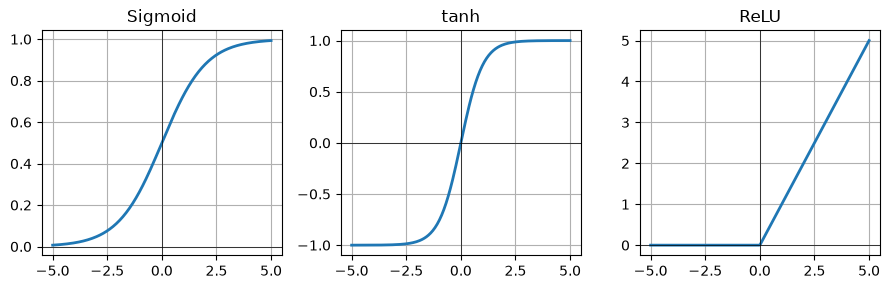

In [24]:
z = np.linspace(-5, 5, 200)
sigmoid = 1 / (1 + np.exp(-z))
tanh = np.tanh(z)
relu = np.maximum(0, z)

plt.figure(figsize=(9, 3))
for i, (name, y) in enumerate([("Sigmoid", sigmoid), ("tanh", tanh), ("ReLU", relu)]):
    plt.subplot(1, 3, i + 1)
    plt.plot(z, y, linewidth=2)
    plt.title(name)
    plt.grid(True)
    plt.axhline(0, color="k", linewidth=0.5)
    plt.axvline(0, color="k", linewidth=0.5)
plt.tight_layout()
plt.show()

Sigmoid und tanh sättigen an den Rändern, ReLU steigt für positive Werte linear an und ist
für negative Werte null.

## 3. Modell aufbauen

In [25]:
def build_model(learning_rate=3e-1, n_hidden=2, n_neurons=300):
    model = keras.models.Sequential()
    model.add(keras.layers.Flatten(input_shape=[28, 28]))
    for _ in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons, activation="relu",
                                     kernel_initializer="he_normal"))
    model.add(keras.layers.Dense(10, activation="softmax"))
    model.compile(loss="sparse_categorical_crossentropy",
                  optimizer=keras.optimizers.SGD(learning_rate=learning_rate),
                  metrics=["accuracy"])
    return model

build_model().summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         3,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,810 (1.25 MB)

 Trainable params: 328,810 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

Das Modell hat zwei verborgene ReLU-Schichten und eine Softmax-Ausgabe mit 10 Neuronen.

## 4. Optimale Lernrate finden

In [26]:
class ExponentialLearningRate(keras.callbacks.Callback):
    def __init__(self, factor):
        self.factor = factor
        self.rates = []
        self.losses = []

    def on_batch_end(self, batch, logs=None):
        lr = float(self.model.optimizer.learning_rate)
        self.rates.append(lr)
        self.losses.append(logs["loss"])
        self.model.optimizer.learning_rate.assign(lr * self.factor)

lr_model = build_model(learning_rate=1e-3)
expon_lr = ExponentialLearningRate(factor=1.005)

history = lr_model.fit(X_train, y_train, epochs=1,
                       validation_data=(X_valid, y_valid),
                       callbacks=[expon_lr])

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5947 - loss: 35233180097183744.0000 - val_accuracy: 0.1126 - val_loss: 2.3911


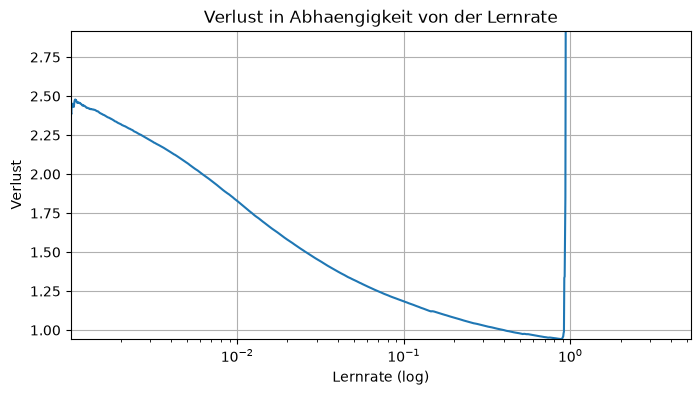

In [27]:
plt.figure(figsize=(8, 4))
plt.plot(expon_lr.rates, expon_lr.losses)
plt.gca().set_xscale("log")
plt.xlabel("Lernrate (log)")
plt.ylabel("Verlust")
plt.title("Verlust in Abhaengigkeit von der Lernrate")
plt.axis([min(expon_lr.rates), max(expon_lr.rates),
          min(expon_lr.losses), expon_lr.losses[0] * 1.2])
plt.grid(True)
plt.show()

Der Verlust fällt zunächst und schießt oberhalb einer bestimmten Lernrate steil nach oben.
Die fürs Training gewählte Lernrate liegt knapp darunter.

## 5. Training mit Checkpoints, Early Stopping und TensorBoard

In [28]:
import os
from time import strftime

def get_run_logdir(root_logdir="my_mnist_logs"):
    run_id = strftime("run_%Y_%m_%d-%H_%M_%S")
    return os.path.join(root_logdir, run_id)

run_logdir = get_run_logdir()

model = build_model(learning_rate=1e-1)

checkpoint_cb = keras.callbacks.ModelCheckpoint("my_mnist_model.keras",
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10,
                                                  restore_best_weights=True)
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)

history = model.fit(X_train, y_train, epochs=100,
                    validation_data=(X_valid, y_valid),
                    callbacks=[checkpoint_cb, early_stopping_cb, tensorboard_cb])

Epoch 1/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9216 - loss: 0.2576 - val_accuracy: 0.9648 - val_loss: 0.1221
Epoch 2/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9692 - loss: 0.1028 - val_accuracy: 0.9726 - val_loss: 0.0896
Epoch 3/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.9805 - loss: 0.0663 - val_accuracy: 0.9762 - val_loss: 0.0812
Epoch 4/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9877 - loss: 0.0452 - val_accuracy: 0.9784 - val_loss: 0.0740
Epoch 5/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9920 - loss: 0.0311 - val_accuracy: 0.9802 - val_loss: 0.0731
Epoch 6/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9951 - loss: 0.0209 - val_accuracy: 0.9792 - val_loss: 0.0760
Epoch 7/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9973 - loss: 0.0139 - val_accuracy: 0.9776 - val_loss: 0.0818
Epoch 8/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - accuracy: 0.9986

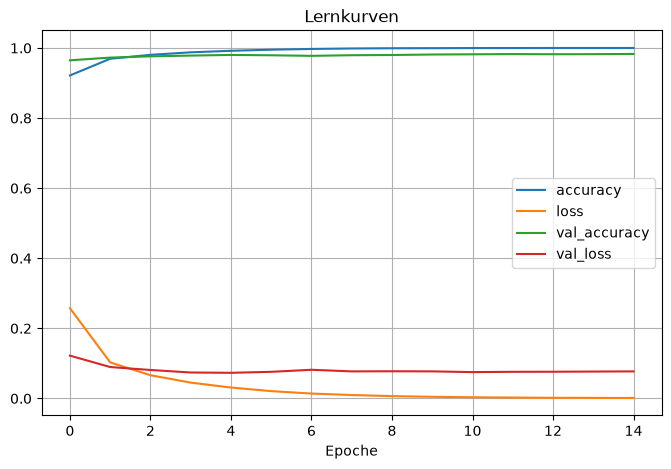

In [29]:
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.title("Lernkurven")
plt.xlabel("Epoche")
plt.show()

Trainings- und Validierungsgenauigkeit steigen rasch an; Early Stopping behält das beste
Modell.

In [30]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test-Genauigkeit: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9782 - loss: 0.0695
Test-Genauigkeit: 0.9782


Das Modell erreicht über 98 % Genauigkeit auf den Testdaten.

## 6. Hyperparameter mit Keras Tuner

In [31]:
import keras_tuner as kt

def build_tuned_model(hp):
    n_hidden = hp.Int("n_hidden", min_value=1, max_value=4, default=2)
    n_neurons = hp.Int("n_neurons", min_value=64, max_value=512, step=64)
    learning_rate = hp.Float("learning_rate", min_value=1e-3, max_value=3e-1,
                             sampling="log")

    model = keras.models.Sequential()
    model.add(keras.layers.Flatten(input_shape=[28, 28]))
    for _ in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons, activation="relu",
                                     kernel_initializer="he_normal"))
    model.add(keras.layers.Dense(10, activation="softmax"))
    model.compile(loss="sparse_categorical_crossentropy",
                  optimizer=keras.optimizers.SGD(learning_rate=learning_rate),
                  metrics=["accuracy"])
    return model

tuner = kt.RandomSearch(
    build_tuned_model,
    objective="val_accuracy",
    max_trials=10,
    overwrite=True,
    directory="my_mnist_tuner",
    project_name="mnist_mlp")

early_stopping_cb = keras.callbacks.EarlyStopping(patience=5,
                                                  restore_best_weights=True)

tuner.search(X_train, y_train, epochs=30,
             validation_data=(X_valid, y_valid),
             callbacks=[early_stopping_cb])

Trial 10 Complete [00h 03m 27s]
val_accuracy: 0.9765999913215637

Best val_accuracy So Far: 0.9829999804496765
Total elapsed time: 00h 40m 35s


In [32]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Beste Hyperparameter:")
for name in ("n_hidden", "n_neurons", "learning_rate"):
    print(f"  {name}: {best_hp.get(name)}")

best_model = tuner.get_best_models(num_models=1)[0]
test_loss, test_acc = best_model.evaluate(X_test, y_test)
print(f"\nTest-Genauigkeit des besten Modells: {test_acc:.4f}")

Beste Hyperparameter:
  n_hidden: 4
  n_neurons: 384
  learning_rate: 0.048124239215040866
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9811 - loss: 0.0735

Test-Genauigkeit des besten Modells: 0.9811


Keras Tuner liefert die beste Kombination aus Schichtzahl, Neuronenzahl und Lernrate.